##### old verzija

In [ ]:
import os
import pandas as pd
from flatten_wind import flatten_wind_blob

folder_path = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\2024_03_Planica_12_winds'

column_vectors = {}
lengths = []

# Loop through all CSV files
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)

        try:
            # Read the file (semicolon-separated)
            df = pd.read_csv(file_path, delimiter=';')

            wind_col_name = df.columns[-1]
            wind_df = df[wind_col_name].apply(flatten_wind_blob)
            df_cleaned = pd.concat([df.drop(columns=[wind_col_name]), wind_df], axis=1)


            if df.shape[0] >= 1 and df.shape[1] >= 6:
                try:
                    x = float(df.iloc[-1, 3])
                    y = float(df.iloc[-1, 4])
                    z = float(df.iloc[-1, 5])
                    length = math.sqrt(x**2 + y**2 + z**2)
                    lengths.append(length)
                except Exception as e:
                    print(f"Skipping vector length in {filename}: {e}")
            else:
                print(f"Skipping vector length in {filename} (not enough columns)")
            
            selected_columns = df_cleaned.columns[16:]

            # Get values from the second row of those columns
            values = df_cleaned.loc[1, selected_columns]

            # Store in vectors by column name
            for col in selected_columns:
                val = values[col]
                if col not in column_vectors:
                    column_vectors[col] = []
                column_vectors[col].append(float(val))

        except Exception as e:
            print(f"Error processing {filename}: {e}")

# --- Optional: Print summary ---
print("Extracted vectors:")
for col, vec in column_vectors.items():
    print(f"{col} ({len(vec)} values): {vec[:5]}...") 
lengths



Extracted vectors:
W1_Speed (218 values): [0.5, 0.8, 1.3, 0.9, 1.1]...
W1_Tangent (218 values): [0.45, 0.49, 1.07, 0.11, -0.01]...
W1_Turbulence (218 values): [0.01, 0.04, 0.11, 0.11, 0.31]...
W1_CleanTan (218 values): [0.45, 0.49, 1.07, 0.11, -0.01]...
W1_Cross (218 values): [0.14, 0.51, 0.63, 0.94, 0.9]...
W2_Speed (218 values): [1.2, 0.9, 2.6, 1.1, 1.1]...
W2_Tangent (218 values): [0.64, 0.82, 2.27, -0.51, 0.75]...
W2_Turbulence (218 values): [0.19, 0.02, 0.44, 0.08, 0.07]...
W2_CleanTan (218 values): [0.64, 0.82, 2.27, -0.51, 0.75]...
W2_Cross (218 values): [0.84, 0.34, 1.02, 0.5, 0.19]...
W3_Speed (218 values): [0.8, 1.2, 1.6, 0.5, 0.7]...
W3_Tangent (218 values): [0.55, 0.67, 1.22, -0.01, 0.19]...
W3_Turbulence (218 values): [0.09, 0.02, 0.2, 0.0, 0.16]...
W3_CleanTan (218 values): [0.55, 0.67, 1.22, -0.01, 0.19]...
W3_Cross (218 values): [0.5, 0.85, 0.38, 0.45, 0.49]...
W4_Speed (218 values): [1.9, 2.1, 1.3, 0.8, 1.3]...
W4_Tangent (218 values): [0.66, 1.14, -0.65, -0.16, -0.51]

[207.11879248392697,
 199.7606487774807,
 229.29820845353328,
 213.45253149119594,
 213.607725281648,
 211.1778513480995,
 233.2731467614736,
 203.54295099560682,
 195.45360805060622,
 203.56941666173728,
 219.36577148680237,
 199.45385932591026,
 223.7171949135783,
 221.80018687999342,
 216.59870059628707,
 197.45661877992342,
 164.01528130024957,
 196.2939583889428,
 210.1301896444202,
 212.66576663863887,
 191.08984405247705,
 185.66868583581885,
 185.18171913015607,
 194.0432804814431,
 171.8737126497243,
 219.07254049743435,
 209.02252964692585,
 203.66466188320447,
 193.23749144511268,
 186.48818166307484,
 181.35469500401692,
 186.14512026910617,
 188.63729959899234,
 138.3992850415059,
 185.05998405922335,
 185.13441063184337,
 165.4204334415794,
 183.82165215229676,
 117.90960859912987,
 179.474739448202,
 179.88638358697415,
 212.84268509864276,
 186.20930723247966,
 194.77093520338195,
 194.16780732139918,
 172.05544629566367,
 201.3618340202532,
 224.37627548383986,
 195.01

### the real stuff

očiščene df shrani v mapo cleaned, poračuna dolžino, vektorje s komponentami, ki so 2. element (1. data vrstica) iz vsakega file

In [ ]:
import os
import math
import pandas as pd
from flatten_wind import *

folder_path = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\2024_03_Planica_12_winds'
clean_folder = os.path.join(folder_path, "cleaned")
os.makedirs(clean_folder, exist_ok=True)

column_vectors = {}
lengths = []

# Loop through all CSV files
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)

        try:
            # Read original CSV (semicolon-separated)
            df = pd.read_csv(file_path, delimiter=';')

            # Extract and flatten wind blob
            wind_col_name = df.columns[-1]
            wind_df = df[wind_col_name].apply(flatten_wind_blob)
            df_cleaned = pd.concat([df.drop(columns=[wind_col_name]), wind_df], axis=1)

            # Convert Time column
            if "Time" in df_cleaned.columns:
                df_cleaned["Time"] = df_cleaned["Time"].apply(timestamp_to_seconds)

            # Convert Y column to float (if not already)
            df_cleaned["Y [m]"] = df_cleaned["Y [m]"].astype(float)
            
            # Now safely check and flip if needed
            if df_cleaned["Y [m]"].iloc[-1] >= 0:
                df_cleaned["Y [m]"] = -df_cleaned["Y [m]"]

            # Save cleaned file
            cleaned_filename = os.path.splitext(filename)[0] + "_cleaned.csv"
            cleaned_path = os.path.join(clean_folder, cleaned_filename)
            df_cleaned.to_csv(cleaned_path, index=False)

            # Original vector logic
            if df.shape[0] >= 1 and df.shape[1] >= 6:
                try:
                    x = float(df.iloc[-1, 3])
                    y = float(df.iloc[-1, 4])
                    z = float(df.iloc[-1, 5])
                    length = math.sqrt(x**2 + y**2 + z**2)
                    lengths.append(length)
                except Exception as e:
                    print(f"Skipping vector length in {filename}: {e}")
            else:
                print(f"Skipping vector length in {filename} (not enough columns)")

            selected_columns = df_cleaned.columns[16:]

            # Get values from the second row of those columns
            if len(df_cleaned) > 1:
                values = df_cleaned.loc[1, selected_columns]

                for col in selected_columns:
                    val = values[col]
                    if col not in column_vectors:
                        column_vectors[col] = []
                    column_vectors[col].append(float(val))

        except Exception as e:
            print(f"Error processing {filename}: {e}")

# --- Optional: Print summary ---
print("Extracted vectors:")
for col, vec in column_vectors.items():
    print(f"{col} ({len(vec)} values): {vec[:5]}...")
print("Lengths:", lengths)


Extracted vectors:
W1_Speed (217 values): [0.5, 0.8, 1.3, 0.9, 1.1]...
W1_Tangent (217 values): [0.45, 0.49, 1.07, 0.11, -0.01]...
W1_Turbulence (217 values): [0.01, 0.04, 0.11, 0.11, 0.31]...
W1_CleanTan (217 values): [0.45, 0.49, 1.07, 0.11, -0.01]...
W1_Cross (217 values): [0.14, 0.51, 0.63, 0.94, 0.9]...
W2_Speed (217 values): [1.2, 0.9, 2.6, 1.1, 1.1]...
W2_Tangent (217 values): [0.64, 0.82, 2.27, -0.51, 0.75]...
W2_Turbulence (217 values): [0.19, 0.02, 0.44, 0.08, 0.07]...
W2_CleanTan (217 values): [0.64, 0.82, 2.27, -0.51, 0.75]...
W2_Cross (217 values): [0.84, 0.34, 1.02, 0.5, 0.19]...
W3_Speed (217 values): [0.8, 1.2, 1.6, 0.5, 0.7]...
W3_Tangent (217 values): [0.55, 0.67, 1.22, -0.01, 0.19]...
W3_Turbulence (217 values): [0.09, 0.02, 0.2, 0.0, 0.16]...
W3_CleanTan (217 values): [0.55, 0.67, 1.22, -0.01, 0.19]...
W3_Cross (217 values): [0.5, 0.85, 0.38, 0.45, 0.49]...
W4_Speed (217 values): [1.9, 2.1, 1.3, 0.8, 1.3]...
W4_Tangent (217 values): [0.66, 1.14, -0.65, -0.16, -0.51]

In [2]:
from flatten_wind import flatten_wind_blob, timestamp_to_seconds

df = pd.read_csv("2024_03_Planica_12_winds/999_999_Jumper_Anon_ANO_1_20240409-103148_C_OfficialResults.csv", sep=';', decimal=',')
wind_col_name = df.columns[-1]


wind_df = df[wind_col_name].apply(flatten_wind_blob)
df_cleaned = pd.concat([df.drop(columns=[wind_col_name]), wind_df], axis=1)

#df_cleaned.to_csv("cleaned_flight_data.csv", index=False)
df_cleaned["Time"] = df_cleaned["Time"].apply(timestamp_to_seconds)


#### top 5 korelacij

In [33]:
import pandas as pd

fixed_vector = pd.Series(lengths)  
correlations = []

for name, values in column_vectors.items():
    try:
        # Convert current vector to Series
        vec_series = pd.Series(values)
        
        # Compute correlation
        corr = fixed_vector.corr(vec_series)
        
        # Store result
        correlations.append((name, corr))
        
    except Exception as e:
        print(f"Error with vector {name}: {e}")

# Sort by absolute value of correlation
correlations_sorted = sorted(correlations, key=lambda x: abs(x[1]), reverse=True)

# Print top 5
print("Top 5 vectors by absolute correlation:")
for name, corr in correlations_sorted[:5]:
    print(f"{name}: correlation = {corr:.4f}")


Top 5 vectors by absolute correlation:
W10_Speed: correlation = 0.2830
W3_Speed: correlation = 0.2125
W11_Tangent: correlation = 0.2084
W11_CleanTan: correlation = 0.2084
W5_Tangent: correlation = 0.2052


#### vizualizacija

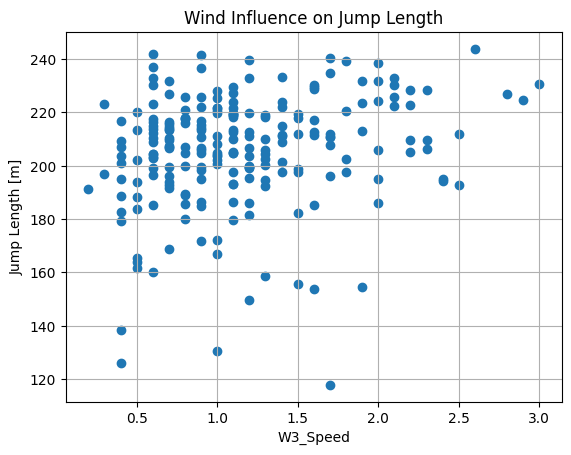

In [34]:
import matplotlib.pyplot as plt

plt.scatter(column_vectors["W3_Speed"], lengths)
plt.xlabel("W3_Speed")
plt.ylabel("Jump Length [m]")
plt.title("Wind Influence on Jump Length")
plt.grid(True)
plt.show()


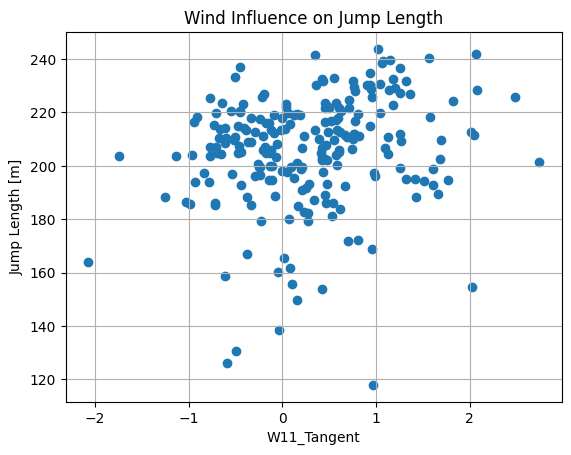

In [29]:
import matplotlib.pyplot as plt

plt.scatter(column_vectors["W11_Tangent"], lengths)
plt.xlabel("W11_Tangent")
plt.ylabel("Jump Length [m]")
plt.title("Wind Influence on Jump Length")
plt.grid(True)
plt.show()

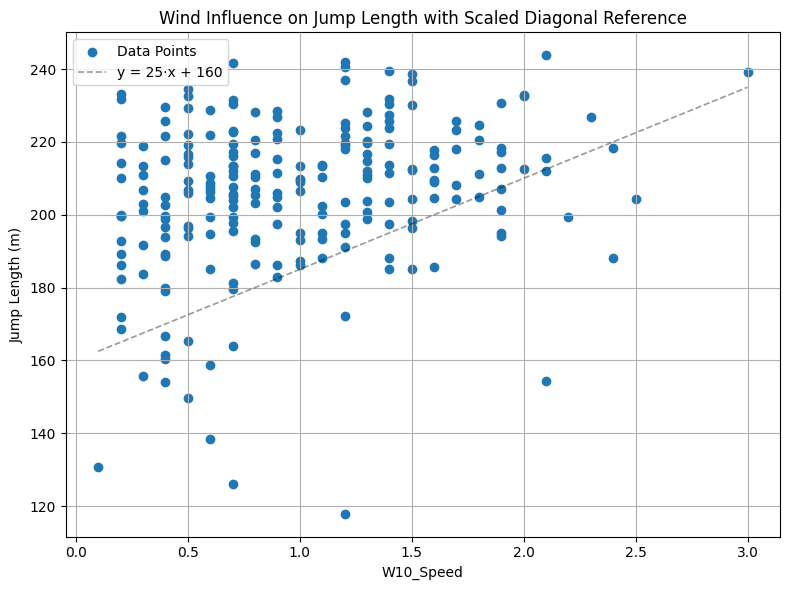

In [31]:
import matplotlib.pyplot as plt

# Example vectors
x = column_vectors["W10_Speed"]
y = lengths

# Adjustable scale and offset
scale = 25     
offset = 160

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, label='Data Points', alpha=1)

# Add y = scale * x + offset line
x_line = [min(x), max(x)]
y_line = [scale * val + offset for val in x_line]
plt.plot(x_line, y_line, 'k--', linewidth=1.2, alpha=0.4, label=f'y = {scale}·x + {offset}')

# Labels and title
plt.xlabel("W10_Speed")
plt.ylabel("Jump Length (m)")
plt.title("Wind Influence on Jump Length with Scaled Diagonal Reference")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#### bolši sample

In [29]:
import os
import math
import pandas as pd
from flatten_wind import *

files_folder_path = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\2024_03_Planica_12_winds\cleaned2'
new_folder = "correlation_vectors"
os.makedirs(new_folder, exist_ok=True)

lengths = []
points = [1, 10, 55, 65, -10, -1]
dict_list = [{} for _ in points]

# Loop through all CSV files
for filename in os.listdir(files_folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(files_folder_path, filename)

        try:
            df = pd.read_csv(file_path, delimiter=',')

            if df.shape[0] >= 1 and df.shape[1] >= 6:
                try:
                    x = float(df.iloc[-1, 3])
                    y = float(df.iloc[-1, 4])
                    z = float(df.iloc[-1, 5])
                    length = math.sqrt(x**2 + y**2 + z**2)
                    lengths.append(length)
                except Exception as e:
                    print(f"Skipping vector length in {filename}: {e}")
            else:
                print(f"Skipping vector length in {filename} (not enough columns)")

            selected_columns = df.columns[16:].insert(0, "Speed hor. [km/h]")    #na 0. mesto dodej 13...index hor. speed

            for i, point in enumerate(points):
                if "dict_id" not in dict_list[i]:
                            dict_list[i]["dict_id"] = []
                dict_list[i]["dict_id"].append(f"{point}" + ". point")
                if "length" not in dict_list[i]:
                            dict_list[i]["length"] = []
                dict_list[i]["length"].append(length)

                if len(df) > 1:
                    values = df.loc[df.index[point], selected_columns]

                    for col in selected_columns:
                        val = values[col]
                        if col not in dict_list[i]:
                            dict_list[i][col] = []
                        dict_list[i][col].append(float(val))
                    
        except Exception as e:
            print(f"Error processing {filename}: {e}")
                    
for i, point in enumerate(dict_list):
    df2 = pd.DataFrame(point)
    df2.to_csv(os.path.join(new_folder, f"point_{points[i]}" + ". point.csv"), index=False)

print("finished")


finished


ideja: vektorje razdelim na 3 dele po conah in pogledam kakšne so njihove korelacije. vzamem samo vektorje iz osamljenih lepih files in jih primerjam s files z napačnim y. 

Mogoče namesto dolžine skoka gledamo kkšno drugo spremenljivko (than again je dolžina ena najbl pomembnih)...maybe korelacija z hitrostjo-horizontalno

data ločimo po conah (start: 0-40, middle: 40:100 , finish: 100-120/149+). Za vsako cono izberemo 2+ točk in pogledamo njihovo korelacijo [lahko najprej samo top 5 pogledamo, da vidmo če se kej loč po senzorjih, če je mogoče vse narobe in je zadnjih par senzorjev ubistvu začetnih,...; kasneje pa dejanska povprečja korelacij and such]

keepamo vektorje za 1. data točko. vzamemo še za 10., enako za točke iz drugih con, pogledamo korelacijo, averagamo korelacijo, gledamo kaj lahko zvemo iz tega.

In [ ]:
#import pandas as pd
#
#
#files_folder_path = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\correlation_vectors'
##new_folder = "correlation_vectors"
##os.makedirs(new_folder, exist_ok=True)
#main = "Speed hor. [km/h]"
#
#
## Loop through all CSV files
#for filename in os.listdir(files_folder_path):
#    if filename.endswith('.csv'):
#        file_path = os.path.join(files_folder_path, filename)
#
#        try:
#            df = pd.read_csv(file_path, delimiter=',')
#            fixed_vector = df[main]  
#            df = df.drop(columns=[main])
#
#            correlations = []
#            for i, colName in enumerate(df.columns):
#                temp = []
#                col = df[colName]
#
#                try:
#                    vec_series = pd.Series(col)
#
#                    corr = fixed_vector.corr(vec_series)
#
#                    temp.append((col, corr))
#
#                except Exception as e:
#                    print(f"Error with vector {col}: {e}")
#        except:
#            print("error")
#
## Sort by absolute value of correlation
#correlations_sorted = sorted(correlations, key=lambda x: abs(x[1]), reverse=True)
#
## Print top 5
#print("Top 5 vectors by absolute correlation:")
#for name, corr in correlations_sorted[:5]:
#    print(f"{name}: correlation = {corr:.4f}")


error
error
error
error
error
error


In [ ]:
import pandas as pd

df = df = pd.read_csv(r"C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\correlation_vectors\point_1. point.csv", delimiter=',')

# Compute Pearson correlation between 'Speed' and 'Wind'
corr = df["Speed hor. [km/h]"].corr(df['W12_Tangent'])

print(f"Correlation between Speed and Wind: {corr:.4f}")


Correlation between Speed and Wind: -0.4426


In [57]:
import pandas as pd
import os
from collections import defaultdict

files_folder_path = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\correlation_vectors'
main = "Speed hor. [km/h]"

# Dictionary for 3 groups
group_correlations = {
    1: defaultdict(list),
    2: defaultdict(list),
    3: defaultdict(list)
}

for filename in os.listdir(files_folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(files_folder_path, filename)

        try:
            df = pd.read_csv(file_path, delimiter=',')

            # Remove non-numeric columns
            df = df.select_dtypes(include=['number'])

            if main not in df.columns:
                print(f"Column '{main}' not found in {filename}. Skipping...")
                continue

            fixed_vector = df[main]
            df = df.drop(columns=[main])
            columns = list(df.columns)

            # Create pairs of two columns
            pairs = [(i, i + 1) for i in range(0, len(columns), 2)]

            # Divide pairs into 3 equal groups
            total_pairs = len(pairs)
            group_size = total_pairs // 3

            groups = {
                1: pairs[:group_size],
                2: pairs[group_size:2 * group_size],
                3: pairs[2 * group_size:]
            }

            # Compute correlations for each group
            for g, pair_list in groups.items():
                for (i1, i2) in pair_list:
                    if i1 < len(columns):
                        col1 = columns[i1]
                        try:
                            corr1 = fixed_vector.corr(df[col1])
                            group_correlations[g][col1].append(corr1)
                        except Exception as e:
                            print(f"Error computing correlation for {col1} in group {g}: {e}")

                    if i2 < len(columns):
                        col2 = columns[i2]
                        try:
                            corr2 = fixed_vector.corr(df[col2])
                            group_correlations[g][col2].append(corr2)
                        except Exception as e:
                            print(f"Error computing correlation for {col2} in group {g}: {e}")

        except Exception as e:
            print(f"Error processing {filename}: {e}")

# Compute average correlation for each variable in each group
avg_group_correlations = {
    g: {var: sum(vals) / len(vals) for var, vals in variables.items() if vals}
    for g, variables in group_correlations.items()
}

# Print Top 5 per group by absolute correlation
print("\n=== Top 5 Variables by Average Absolute Correlation for Each Group ===")
for g in avg_group_correlations:
    print(f"\nGroup {g}:")
    sorted_vars = sorted(avg_group_correlations[g].items(), key=lambda x: abs(x[1]), reverse=True)
    for var, avg_corr in sorted_vars[:5]:
        print(f"  {var}: avg correlation = {avg_corr:.4f}")



=== Top 5 Variables by Average Absolute Correlation for Each Group ===

Group 1:
  W3_Tangent: avg correlation = -0.3477
  W3_CleanTan: avg correlation = -0.3477
  W1_Tangent: avg correlation = -0.3313
  W1_CleanTan: avg correlation = -0.3313
  W1_Cross: avg correlation = 0.3225

Group 2:
  W8_Tangent: avg correlation = -0.4771
  W8_CleanTan: avg correlation = -0.4771
  W7_Tangent: avg correlation = -0.4184
  W7_CleanTan: avg correlation = -0.4184
  W6_Tangent: avg correlation = -0.3996

Group 3:
  W12_Tangent: avg correlation = -0.4566
  W12_CleanTan: avg correlation = -0.4566
  W9_Tangent: avg correlation = -0.4518
  W9_CleanTan: avg correlation = -0.4518
  W10_Tangent: avg correlation = -0.4142


### ločevanje

In [ ]:
import os
import math
import pandas as pd
from flatten_wind import *

folder_path = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\2024_03_Planica_12_winds'
clean_folder = os.path.join(folder_path, "cleaned_negativeY")
os.makedirs(clean_folder, exist_ok=True)

column_vectors = {}
lengths = []

# Loop through all CSV files
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)

        try:
            # Read original CSV (semicolon-separated)
            df = pd.read_csv(file_path, delimiter=';')

            # Extract and flatten wind blob
            wind_col_name = df.columns[-1]
            wind_df = df[wind_col_name].apply(flatten_wind_blob)
            df_cleaned = pd.concat([df.drop(columns=[wind_col_name]), wind_df], axis=1)

            # Convert Time column
            if "Time" in df_cleaned.columns:
                df_cleaned["Time"] = df_cleaned["Time"].apply(timestamp_to_seconds)

            # Convert Y column to float (if not already)
            df_cleaned["Y [m]"] = df_cleaned["Y [m]"].astype(float)
            
            # Now safely check and flip if needed
            if df_cleaned["Y [m]"].iloc[-1] < 0:
                continue

            # Save cleaned file
            cleaned_filename = os.path.splitext(filename)[0] + "_cleaned_negativeY.csv"
            cleaned_path = os.path.join(clean_folder, cleaned_filename)
            df_cleaned.to_csv(cleaned_path, index=False)

        except Exception as e:
            print(f"Error processing {filename}: {e}")


In [59]:
import os
import math
import pandas as pd
from flatten_wind import *

files_folder_path = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\2024_03_Planica_12_winds\cleaned_negativeY'
new_folder = "correlation_vectors_negativeY"
os.makedirs(new_folder, exist_ok=True)

lengths = []
points = [1, 10, 55, 65, -10, -1]
dict_list = [{} for _ in points]

# Loop through all CSV files
for filename in os.listdir(files_folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(files_folder_path, filename)

        try:
            df = pd.read_csv(file_path, delimiter=',')

            if df.shape[0] >= 1 and df.shape[1] >= 6:
                try:
                    x = float(df.iloc[-1, 3])
                    y = float(df.iloc[-1, 4])
                    z = float(df.iloc[-1, 5])
                    length = math.sqrt(x**2 + y**2 + z**2)
                    lengths.append(length)
                except Exception as e:
                    print(f"Skipping vector length in {filename}: {e}")
            else:
                print(f"Skipping vector length in {filename} (not enough columns)")

            selected_columns = df.columns[16:].insert(0, "Speed hor. [km/h]")    #na 0. mesto dodej 13...index hor. speed

            for i, point in enumerate(points):
                if "dict_id" not in dict_list[i]:
                            dict_list[i]["dict_id"] = []
                dict_list[i]["dict_id"].append(f"{point}" + ". point")
                if "length" not in dict_list[i]:
                            dict_list[i]["length"] = []
                dict_list[i]["length"].append(length)

                if len(df) > 1:
                    values = df.loc[df.index[point], selected_columns]

                    for col in selected_columns:
                        val = values[col]
                        if col not in dict_list[i]:
                            dict_list[i][col] = []
                        dict_list[i][col].append(float(val))
                    
        except Exception as e:
            print(f"Error processing {filename}: {e}")
                    
for i, point in enumerate(dict_list):
    df2 = pd.DataFrame(point)
    df2.to_csv(os.path.join(new_folder, f"point_{points[i]}" + ". point.csv"), index=False)

print("finished")


finished


In [60]:
import pandas as pd
import os
from collections import defaultdict

files_folder_path = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\correlation_vectors_negativeY'
main = "Speed hor. [km/h]"

# Dictionary for 3 groups
group_correlations = {
    1: defaultdict(list),
    2: defaultdict(list),
    3: defaultdict(list)
}

for filename in os.listdir(files_folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(files_folder_path, filename)

        try:
            df = pd.read_csv(file_path, delimiter=',')

            # Remove non-numeric columns
            df = df.select_dtypes(include=['number'])

            if main not in df.columns:
                print(f"Column '{main}' not found in {filename}. Skipping...")
                continue

            fixed_vector = df[main]
            df = df.drop(columns=[main])
            columns = list(df.columns)

            # Create pairs of two columns
            pairs = [(i, i + 1) for i in range(0, len(columns), 2)]

            # Divide pairs into 3 equal groups
            total_pairs = len(pairs)
            group_size = total_pairs // 3

            groups = {
                1: pairs[:group_size],
                2: pairs[group_size:2 * group_size],
                3: pairs[2 * group_size:]
            }

            # Compute correlations for each group
            for g, pair_list in groups.items():
                for (i1, i2) in pair_list:
                    if i1 < len(columns):
                        col1 = columns[i1]
                        try:
                            corr1 = fixed_vector.corr(df[col1])
                            group_correlations[g][col1].append(corr1)
                        except Exception as e:
                            print(f"Error computing correlation for {col1} in group {g}: {e}")

                    if i2 < len(columns):
                        col2 = columns[i2]
                        try:
                            corr2 = fixed_vector.corr(df[col2])
                            group_correlations[g][col2].append(corr2)
                        except Exception as e:
                            print(f"Error computing correlation for {col2} in group {g}: {e}")

        except Exception as e:
            print(f"Error processing {filename}: {e}")

# Compute average correlation for each variable in each group
avg_group_correlations = {
    g: {var: sum(vals) / len(vals) for var, vals in variables.items() if vals}
    for g, variables in group_correlations.items()
}

# Print Top 5 per group by absolute correlation
print("\n=== Top 5 Variables by Average Absolute Correlation for Each Group ===")
for g in avg_group_correlations:
    print(f"\nGroup {g}:")
    sorted_vars = sorted(avg_group_correlations[g].items(), key=lambda x: abs(x[1]), reverse=True)
    for var, avg_corr in sorted_vars[:5]:
        print(f"  {var}: avg correlation = {avg_corr:.4f}")



=== Top 5 Variables by Average Absolute Correlation for Each Group ===

Group 1:
  W3_Tangent: avg correlation = -0.3932
  W3_CleanTan: avg correlation = -0.3932
  W2_Tangent: avg correlation = -0.3557
  W2_CleanTan: avg correlation = -0.3557
  W1_Tangent: avg correlation = -0.3450

Group 2:
  W7_Tangent: avg correlation = -0.4395
  W7_CleanTan: avg correlation = -0.4395
  W8_Tangent: avg correlation = -0.3740
  W8_CleanTan: avg correlation = -0.3740
  W5_Tangent: avg correlation = -0.3307

Group 3:
  W9_Tangent: avg correlation = -0.3916
  W9_CleanTan: avg correlation = -0.3916
  W10_Tangent: avg correlation = -0.3733
  W10_CleanTan: avg correlation = -0.3733
  W11_Tangent: avg correlation = -0.3091
